## 1: Loading XA+NA TV reconstruction and correcting for phase artifacts at edge
(XA: Xray, slice A, NA: Neutron slice A, DA: Diffraction slice A)

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import os
os.chdir('/zhome/71/c/146676/main/')
from helpers import module_auxiliary as ma
from loaders import stitcher_XA
from loaders import loader_XA_to_NA
import SimpleITK as sitk
import copy

In [2]:
xray_slices = range(0,2800) # Which xray slices to load? Starting from around 0 to around 3200
neutron_slices = range(0,1650) # Which neutron slices to load? Starting from 0 to around 1700. Slice 0 are at different ends of the meteorite
output_volume = [[0,1650],[None], [None]] # The slices included in the arrays that the registerred volumes are saved to (just set first coordinate 
# equal the numbers in Neutron slices, and the others to None (indicating to include all the data))


# Now read the datafrom disc, and register XA to NA. h=1 indicates that the neutron resolution should be used. Setting h higher, you can take advantage
# of the higher resolution of the xray data, but this requires changing output_volume
reg = loader_XA_to_NA.load_subset_of_registered_data(dataset_XA='tv', dataset_NA='tv' , h=1, xray_slices = xray_slices,
    neutron_slices = neutron_slices, output_volume = output_volume)

Loading xray data
Loading neutron data
Resampling the transformation
Resampling moving image


#### Convert to np arrays

In [3]:
XA = sitk.GetArrayFromImage(reg.moving)
NA = sitk.GetArrayFromImage(reg.fixed)

#### Create a function that can segment the volume into rock/air

In [4]:
def segment_rock(input_image, threshold = 0.01):
    # Downsample by factor of 3
    # Compute new size and spacing
    factor = 3
    new_size = [int(s / factor) for s in input_image.GetSize()]
    new_spacing = [s * factor for s in input_image.GetSpacing()]

    # Resample the image (downsampling)
    resample = sitk.ResampleImageFilter()
    resample.SetSize(new_size)
    resample.SetOutputSpacing(new_spacing)
    resample.SetInterpolator(sitk.sitkLinear)
    resample.SetOutputOrigin(input_image.GetOrigin())  # Copy origin
    resample.SetOutputDirection(input_image.GetDirection())  # Copy direction
    downsampled_image = resample.Execute(input_image)


    # Apply Gaussian smoothing
    smoothed_image = sitk.SmoothingRecursiveGaussian(downsampled_image, sigma=0.01)

    # Threshold-based segmentation (choose a threshold manually)
    lower_threshold = threshold  # Change this value based on your data
    upper_threshold = 255
    binary_image = sitk.BinaryThreshold(smoothed_image, lowerThreshold=lower_threshold, upperThreshold=upper_threshold, insideValue=1, outsideValue=0)

    # **Keep only the largest connected component of class 1 (object)**
    cc_object = sitk.ConnectedComponent(binary_image)  # Label connected regions
    object_sizes = sitk.LabelShapeStatisticsImageFilter()
    object_sizes.Execute(cc_object)
    largest_label = max(object_sizes.GetLabels(), key=lambda l: object_sizes.GetPhysicalSize(l))
    largest_object = sitk.BinaryThreshold(cc_object, lowerThreshold=largest_label, upperThreshold=largest_label, insideValue=1, outsideValue=0)

    # **Keep only the largest connected component of class 0 (background)**
    inverted_binary = sitk.BinaryNot(largest_object)  # Invert image
    cc_background = sitk.ConnectedComponent(inverted_binary)
    background_sizes = sitk.LabelShapeStatisticsImageFilter()
    background_sizes.Execute(cc_background)
    largest_label_bg = max(background_sizes.GetLabels(), key=lambda l: background_sizes.GetPhysicalSize(l))
    largest_background = sitk.BinaryThreshold(cc_background, lowerThreshold=largest_label_bg, upperThreshold=largest_label_bg, insideValue=1, outsideValue=0)

    # Invert background back to 0
    final_segmented = sitk.BinaryNot(largest_background)

    # Resample back to original resolution (upsampling)
    resample.SetSize(input_image.GetSize())
    resample.SetOutputSpacing(input_image.GetSpacing())
    resample.SetInterpolator(sitk.sitkNearestNeighbor)  
    resample.SetOutputOrigin(input_image.GetOrigin())  
    resample.SetOutputDirection(input_image.GetDirection())  
    final_segmented = resample.Execute(final_segmented)
    return final_segmented

#### Get NP arrays of the segmentations

In [5]:
XA_e = sitk.GetArrayFromImage(segment_rock(reg.moving, threshold = 0.010)).astype(bool).astype(np.int8)
NA_e = sitk.GetArrayFromImage(segment_rock(reg.fixed, threshold = 0.015)).astype(bool).astype(np.int8)

#### Extract upper and lower outer edges of both XA and NA recons

In [6]:
NA_d = np.diff(NA_e,axis=1)
edge_index_NA_lower = np.argmax(NA_d[:,40:-40], axis=1)+40
edge_index_NA_lower[np.all(NA_d == False, axis=1)] = -1
edge_index_NA_lower = np.clip(edge_index_NA_lower*NA_e[:,90],a_min=10,a_max=350)

NA_d = np.diff(NA_e,axis=1)
rev_first_true_idx = np.argmax(NA_e[:, -40:40:-1, :], axis=1)+40
edge_index_NA_upper= NA_e.shape[1] - 1 - rev_first_true_idx
edge_index_NA_upper[np.all(NA_e == False, axis=1)] = -1
edge_index_NA_upper = np.clip(edge_index_NA_upper,a_min=10,a_max=350)

XA_d = np.diff(XA_e,axis=1)
edge_index_XA_lower = np.argmax(XA_d[:,40:-40], axis=1)+40
edge_index_XA_lower[np.all(XA_d == False, axis=1)] = -1
edge_index_XA_lower = np.clip(edge_index_XA_lower*XA_e[:,90],a_min=10,a_max=350)

NA_d = np.diff(NA_e,axis=1)
rev_first_true_idx = np.argmax(XA_e[:, -40:40:-1, :], axis=1)+40
edge_index_XA_upper= XA_e.shape[1] - 1 - rev_first_true_idx
edge_index_XA_upper[np.all(XA_e == False, axis=1)] = -1
edge_index_XA_upper = np.clip(edge_index_XA_upper,a_min=10,a_max=350)


#### Display a plot of the indices of the outer edge: Does it look plausible? Test XA_upper, XA_lower, NA_upper, NA_lower

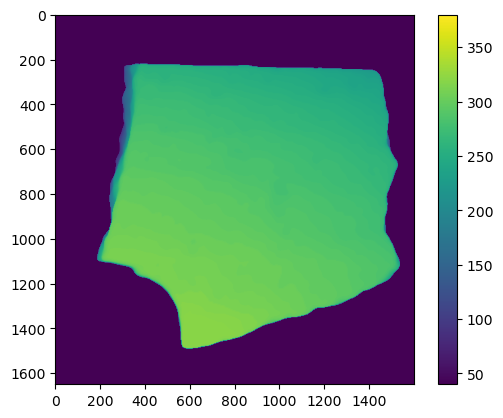

In [7]:
plt.imshow(edge_index_XA_upper)
plt.colorbar()
plt.clim([40,380])

#### Do mean normalization a distance "i" from each edge

"i" goes from 0 to 50 pixels into the image

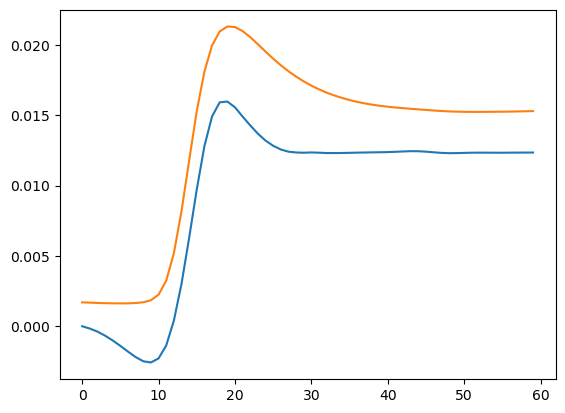

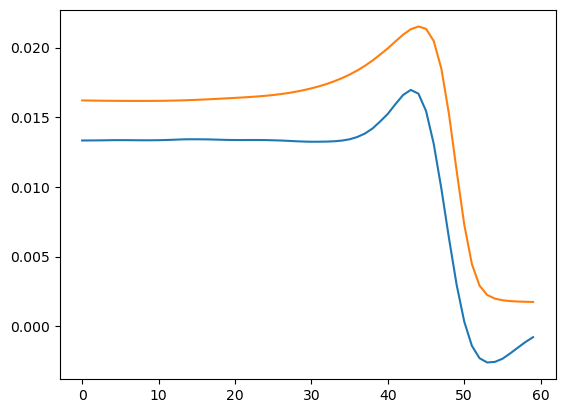

In [8]:
XA_corrected = copy.deepcopy(XA)
NA_corrected = copy.deepcopy(NA)
nz, ny, nx = np.shape(NA)

phase_artifact_range = np.arange(-10,50)
phase_means_NA_lower = np.zeros(np.shape(phase_artifact_range))
phase_means_XA_lower = np.zeros(np.shape(phase_artifact_range))
for i in range(len(phase_artifact_range)):
    edge_layer_NA = NA[np.arange(nz)[:, None], edge_index_NA_lower+phase_artifact_range[i], np.arange(nx)]
    phase_means_NA_lower[i] = np.mean(edge_layer_NA)
    edge_layer_XA = XA[np.arange(nz)[:, None], edge_index_XA_lower+phase_artifact_range[i], np.arange(nx)]
    phase_means_XA_lower[i] = np.mean(edge_layer_XA)

background_mean_NA_lower = np.mean(phase_means_NA_lower[-10:])
background_mean_XA_lower = np.mean(phase_means_XA_lower[-10:])

for i in range(9,60):
    NA_corrected[np.arange(nz)[:, None], edge_index_NA_lower+phase_artifact_range[i], np.arange(nx)] =\
        NA[np.arange(nz)[:, None], edge_index_NA_lower+phase_artifact_range[i], np.arange(nx)] -\
        phase_means_NA_lower[i]+ background_mean_NA_lower
    
    XA_corrected[np.arange(nz)[:, None], edge_index_XA_lower+phase_artifact_range[i], np.arange(nx)] =\
        XA[np.arange(nz)[:, None], edge_index_XA_lower+phase_artifact_range[i], np.arange(nx)] -\
         phase_means_XA_lower[i]+ background_mean_XA_lower



phase_artifact_range = np.arange(-50,10)
phase_means_NA_upper = np.zeros(np.shape(phase_artifact_range))
phase_means_XA_upper = np.zeros(np.shape(phase_artifact_range))
for i in range(len(phase_artifact_range)):
    edge_layer_NA = NA[np.arange(nz)[:, None], edge_index_NA_upper+phase_artifact_range[i], np.arange(nx)]
    phase_means_NA_upper[i] = np.mean(edge_layer_NA)
    edge_layer_XA = XA[np.arange(nz)[:, None], edge_index_XA_upper+phase_artifact_range[i], np.arange(nx)]
    phase_means_XA_upper[i] = np.mean(edge_layer_XA)

background_mean_NA_upper = np.mean(phase_means_NA_upper[:10])
background_mean_XA_upper = np.mean(phase_means_XA_upper[:10])

for i in range(0,50):
    NA_corrected[np.arange(nz)[:, None], edge_index_NA_upper+phase_artifact_range[i], np.arange(nx)] =\
        NA[np.arange(nz)[:, None], edge_index_NA_upper+phase_artifact_range[i], np.arange(nx)] -\
        phase_means_NA_upper[i]+ background_mean_NA_upper
    
    XA_corrected[np.arange(nz)[:, None], edge_index_XA_upper+phase_artifact_range[i], np.arange(nx)] =\
        XA[np.arange(nz)[:, None], edge_index_XA_upper+phase_artifact_range[i], np.arange(nx)] -\
         phase_means_XA_upper[i]+ background_mean_XA_upper


plt.plot(phase_means_XA_lower)
plt.plot(phase_means_NA_lower)
plt.show()

plt.plot(phase_means_XA_upper)
plt.plot(phase_means_NA_upper)
plt.show()

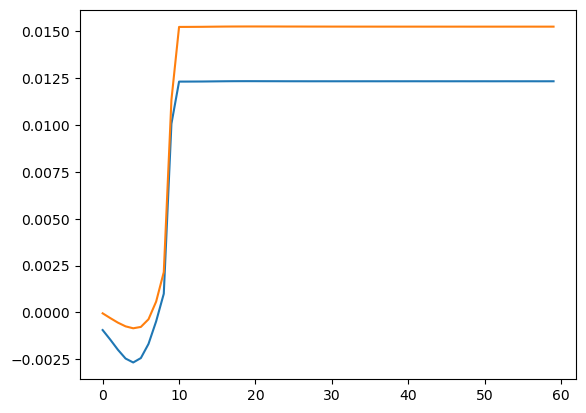

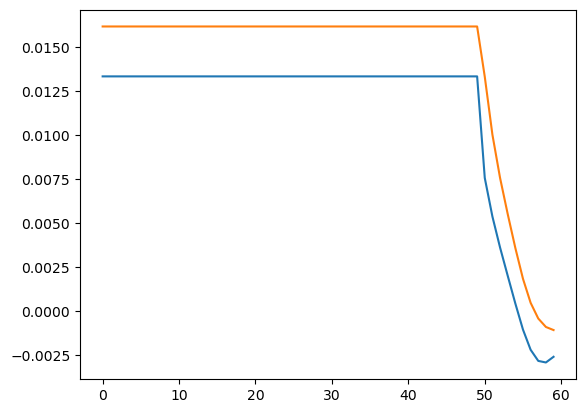

In [9]:
phase_artifact_range = np.arange(-10,50)
phase_means_NA_lower = np.zeros(np.shape(phase_artifact_range))
phase_means_XA_lower = np.zeros(np.shape(phase_artifact_range))
for i in range(len(phase_artifact_range)):
    edge_layer_NA = NA_corrected[np.arange(nz)[:, None], edge_index_NA_lower+phase_artifact_range[i], np.arange(nx)]
    phase_means_NA_lower[i] = np.mean(edge_layer_NA)
    edge_layer_XA = XA_corrected[np.arange(nz)[:, None], edge_index_XA_lower+phase_artifact_range[i], np.arange(nx)]
    phase_means_XA_lower[i] = np.mean(edge_layer_XA)

phase_artifact_range = np.arange(-50,10)
phase_means_NA_upper = np.zeros(np.shape(phase_artifact_range))
phase_means_XA_upper = np.zeros(np.shape(phase_artifact_range))
for i in range(len(phase_artifact_range)):
    edge_layer_NA = NA_corrected[np.arange(nz)[:, None], edge_index_NA_upper+phase_artifact_range[i], np.arange(nx)]
    phase_means_NA_upper[i] = np.mean(edge_layer_NA)
    edge_layer_XA = XA_corrected[np.arange(nz)[:, None], edge_index_XA_upper+phase_artifact_range[i], np.arange(nx)]
    phase_means_XA_upper[i] = np.mean(edge_layer_XA)

plt.plot(phase_means_XA_lower)
plt.plot(phase_means_NA_lower)
plt.show()

plt.plot(phase_means_XA_upper)
plt.plot(phase_means_NA_upper)
plt.show()


#### Let's see the effect of the change:

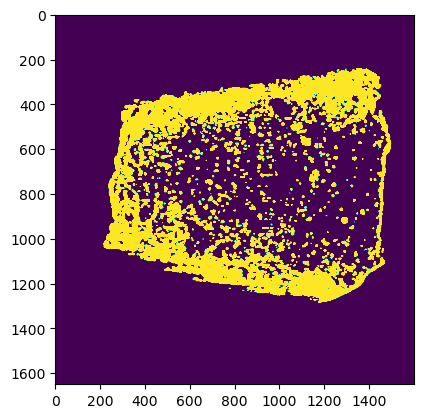

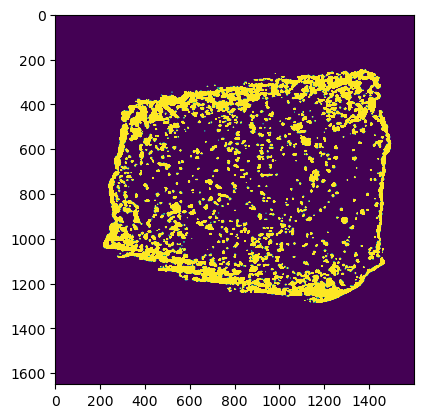

In [10]:
plt.close('all')
plt.imshow(NA[:,80]>0.035)
plt.clim([0,0.05])
plt.show()
plt.imshow(NA_corrected[:,80]>0.035)
plt.clim([0,0.05])
plt.show()

#### This should reduce the thickness of the edge

#### You can now do analysis on XA_corrected and NA_corrected!

Some options: Save them to disc, or copy paste the stuff above into a script, and run this script before doing the analyis. The bottleneck is to read the volumes from disc to RAM in both cases

## Register to DA

#### Load the specific part of the volumes that match with diffraction data

In [24]:
XA_d = XA[600-output_volume[0][0]:1000-output_volume[0][0]]
NA_d = NA_corrected[600-output_volume[0][0]:1000-output_volume[0][0]]

#### Load the diffraction data

In [25]:
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/overview_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset = f["absorption"]
    DA = dataset[:,120:240]

Keys: ['absorption']


#### Register XA with DA (and do NA later). Step 1: Cast to SITK images

In [26]:
_ , nx_XA = np.shape(XA_d[0])
_ , nx_DA_2 = np.shape(DA[0])

fixed = sitk.GetImageFromArray(DA)
moving = sitk.GetImageFromArray(XA_d)
fixed.SetSpacing((1/nx_DA_2,1/nx_DA_2,1/nx_DA_2))
moving.SetSpacing((1/nx_XA,1/nx_XA,1/nx_XA))

size_fixed = fixed.GetSize()
size_moving = moving.GetSize()

spacing_fixed = fixed.GetSpacing()
spacing_moving = moving.GetSpacing()

# Compute the new origin (shift it to -N/2)
new_origin_fixed = [-0.5 * (size_fixed[i] - 1) * spacing_fixed[i] for i in range(len(size_fixed))]
new_origin_moving = [-0.5 * (size_moving[i] - 1) * spacing_moving[i] for i in range(len(size_moving))]

fixed.SetOrigin(new_origin_fixed)
moving.SetOrigin(new_origin_moving)

#### Define the registration optimizer and resampler

In [96]:
def registrator(fixed, moving, thresholds = [0.0045, 0.025], sampling_percentage = 0.1, max_iter = 1000, learning_rate = 1):

    fixed_d = sitk.BinaryThreshold(fixed, lowerThreshold=thresholds[0], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    moving_d = sitk.BinaryThreshold(moving, lowerThreshold=thresholds[1], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    fixed_d =sitk.Cast(fixed_d, sitk.sitkFloat32)
    moving_d =sitk.Cast(moving_d, sitk.sitkFloat32)

    initial_transform = sitk.Similarity3DTransform()
    initial_transform.SetMatrix([1.0, 0.0, 0.0,
                                0.0, 1.0, 0.0,
                                0.0, 0.0, 1.0])

    # Set the translation to zero
    initial_transform.SetTranslation([0.0, 0.0, 0.0])
    initial_transform.SetScale(1.0)

    registration = sitk.ImageRegistrationMethod()
    registration.SetInitialTransform(initial_transform)
    registration.SetMetricAsMeanSquares()
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(sampling_percentage)

    registration.SetOptimizerAsGradientDescent(
        learningRate=learning_rate,
        numberOfIterations=max_iter,
        convergenceMinimumValue=-1e-16,
        convergenceWindowSize=1000
        )

    registration.SetInterpolator(sitk.sitkLinear)
    registration.Execute(fixed_d, moving_d)
    transform = registration.GetInitialTransform()
    return transform

def resampler(fixed, moving, transform):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed)  # Reference image (fixed)
    resampler.SetInterpolator(sitk.sitkLinear)   # Interpolation method
    resampler.SetTransform(transform)    # Apply the initial transform (aligned centroids)
    resampler.SetOutputPixelType(fixed.GetPixelID())
    resampler.SetOutputSpacing(fixed.GetSpacing())  # Ensure the spacing is preserved
    resampler.SetOutputOrigin(fixed.GetOrigin())  # Preserve origin
    resampler.SetOutputDirection(fixed.GetDirection())
    moving = resampler.Execute(moving)
    return moving

In [44]:
transform1 = registrator(fixed, moving, thresholds = [0.0045, 0.025], sampling_percentage = 0.6, max_iter = 1000, learning_rate = 0.3)
moving_temp = resampler(fixed, moving, transform1)


In [45]:

transform2 = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 400, learning_rate = 0.2)
moving_temp = resampler(fixed, moving_temp, transform2)


transform3 = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 400, learning_rate = 0.1)
moving_temp = resampler(fixed, moving_temp, transform3)

transform4 = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 400, learning_rate = 0.05)
moving_temp = resampler(fixed, moving_temp, transform4)

transform5 = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 400, learning_rate = 0.03)
moving_temp = resampler(fixed, moving_temp, transform5)

transform6 = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 400, learning_rate = 0.01)
moving_temp = resampler(fixed, moving_temp, transform6)

In [ ]:
composite_transform = sitk.CompositeTransform(3)

# Add transformations in order
composite_transform.AddTransform(transform1)
composite_transform.AddTransform(transform2)
composite_transform.AddTransform(transform3)
composite_transform.AddTransform(transform4)
composite_transform.AddTransform(transform5)
composite_transform.AddTransform(transform6)
sitk.WriteTransform(composite_transform, "transformation_NA_to_DA_slice_600_to_1000.tfm")

In [53]:
transform = sitk.ReadTransform("transformation_NA_to_DA_slice_600_to_1000.tfm")
moving_temp = resampler(fixed, moving, transform)

In [54]:
def plotter(XA_temp = moving_temp, DA_2 = DA):
    plt.imshow(XA_temp[10])
    plt.clim([0.01,0.07])
    plt.show()

    plt.imshow(XA_temp[:,50])
    plt.clim([0.01,0.07])
    plt.show()

    plt.imshow(DA_2[10])
    plt.show()

    plt.imshow(DA_2[:,50])
    plt.show()

    thresholds = [0.0045, 0.025]
    plt.imshow(XA_temp[10]>thresholds[1])
    plt.clim([0.01,0.07])
    plt.show()

    plt.imshow(DA_2[10] > thresholds[0])
    plt.show()

    plt.imshow((DA_2[10] > thresholds[0])*1.0 - (XA_temp[10] > thresholds[1])*1.0)
    plt.show()

    plt.imshow(XA_temp[:,50]>thresholds[1])
    plt.clim([0.012,0.075])
    plt.show()

    plt.imshow(DA_2[:,50] > thresholds[0])
    plt.show()

    plt.imshow((DA_2[:,50] > thresholds[0])*1.0 - (XA_temp[:,50] > thresholds[1])*1.0)
    plt.show()

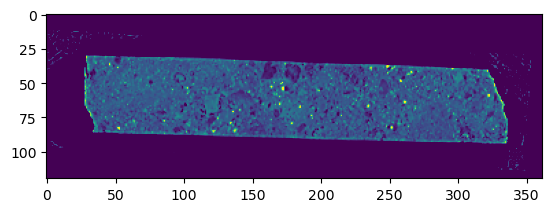

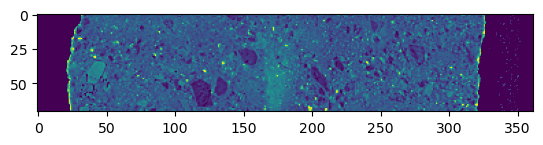

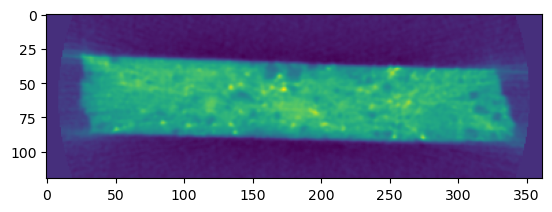

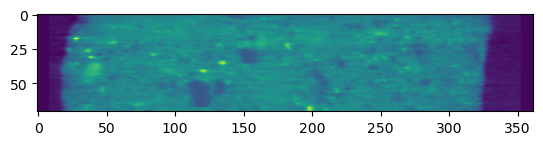

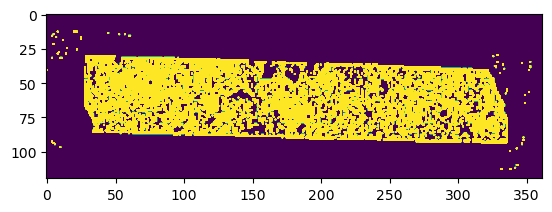

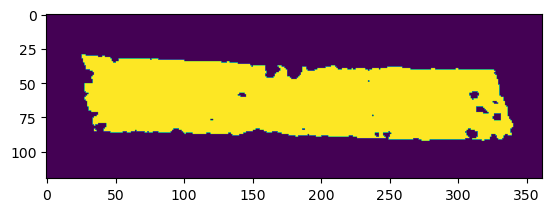

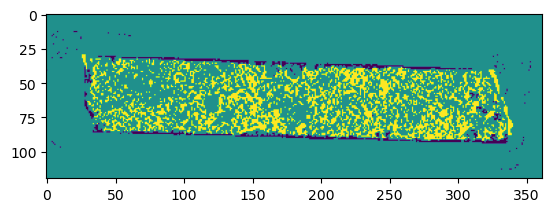

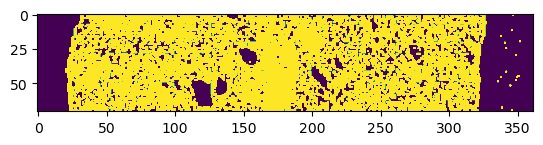

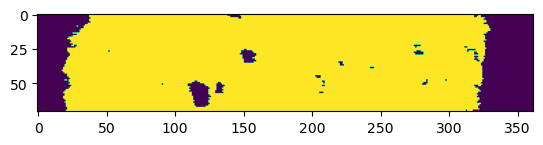

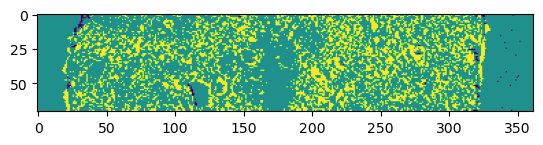

In [55]:
XA_temp = sitk.GetArrayFromImage(moving_temp)
plotter(XA_temp = XA_temp, DA_2 = DA)

In [98]:
def resampler(fixed, moving, transform):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed)  # Reference image (fixed)
    resampler.SetInterpolator(sitk.sitkLinear)   # Interpolation method
    resampler.SetTransform(transform)    # Apply the initial transform (aligned centroids)
    resampler.SetOutputPixelType(fixed.GetPixelID())
    resampler.SetOutputSpacing(fixed.GetSpacing())  # Ensure the spacing is preserved
    resampler.SetOutputOrigin(fixed.GetOrigin())  # Preserve origin
    resampler.SetOutputDirection(fixed.GetDirection())
    moving = resampler.Execute(moving)
    return moving
    
def resampler2(fixed, moving, transform, h=1):
    high_res=moving
    low_res=fixed
    # Get the spacing and size for the high-resolution image
    high_res_spacing = high_res.GetSpacing()
    high_res_size = high_res.GetSize()
    low_res_spacing = low_res.GetSpacing()
    low_res_size = low_res.GetSize()

    # Define the scaling factor
    scaling_factor = h  # Halve the spacing, double the size

    # Create the resampling filter
    resampler = sitk.ResampleImageFilter()

    # Set the output size (double the size)
    new_size = [int(dim * scaling_factor) for dim in low_res_size]

    # Set the output spacing (half the spacing)
    new_spacing = [spacing / scaling_factor for spacing in low_res_spacing]

    # Configure the resampler
    resampler.SetReferenceImage(low_res)  # Use the high-res image as reference
    resampler.SetSize(new_size)  # Set the new size
    resampler.SetOutputSpacing(new_spacing)  # Correct way to set spacing
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetTransform(transform)  # Apply the transformation
    resampler.SetOutputPixelType(fixed.GetPixelID())
    resampler.SetOutputOrigin(fixed.GetOrigin())  # Preserve origin
    resampler.SetOutputDirection(fixed.GetDirection())

    # Perform resampling
    return resampler.Execute(high_res)


In [101]:
resampled_high_res = resampler2(fixed, moving, transform, h=1)
resampled = resampler(fixed, moving, transform)

In [102]:
high_res_out = sitk.GetArrayFromImage(resampled_high_res)
res_out = sitk.GetArrayFromImage(resampled)

In [103]:
print(np.shape(high_res_out))
print(np.shape(DA))


(71, 120, 362)
(71, 120, 362)


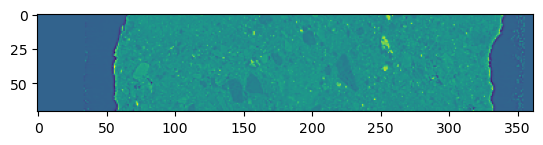

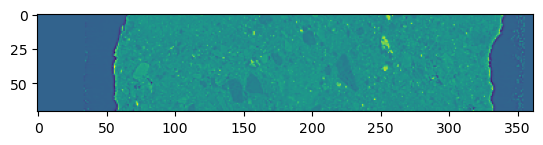

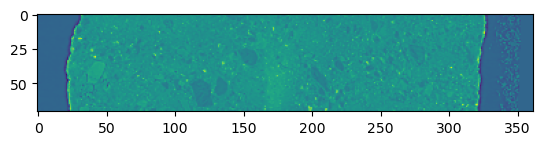

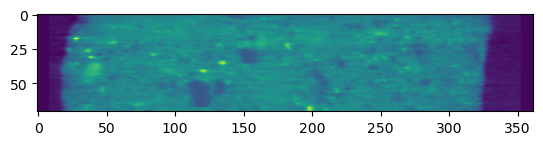

In [ ]:
plt.imshow(high_res_out[:,50])
plt.show()
plt.imshow(res_out[:,50])
plt.show()
plt.imshow(XA_temp[:,50])
plt.show()
plt.imshow(DA[:,50])